# 01 - Baseline par seuillage

## La méthode classique est le seuillage couleur RGB.

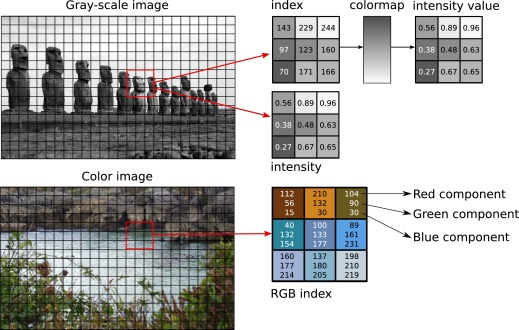

Une image numérique est composée de **pixels**. Chaque pixel possède généralement trois valeurs :
- R - Rouge
- G - Vert
- B - Bleu
(RGB)

Donc un pixel peut être représenté comme : **Pixel =  (R, G, B)**


### Une idée est très simple : 
on regarde la couleur des pixels dans une image, puis on décide si chaque pixel ressemble à de l’eau ou non.


Dans une méthode simple de seuillage couleur, on peut estimer les regles suivantes :

**Si le bleu est dominant, alors le pixel est probablement de l’eau.
Sinon, ce n’est pas de l’eau.**

#### Exemple de règle naïve :


```
Si B > R
et B > G
alors eau.
```

Le résultat est un masque binaire : 
- **0 (pas d'eau)** 
- **1 (eau)**


Donc à partir de l’image originale, on obtient une image noir/blanc où les pixels blancs représentent l’eau détectée.
Le problème, c’est que cette méthode suppose que l’eau est visuellement “bleue” ou très reconnaissable par couleur. Or, dans ton projet, l’eau industrielle peut être grise, marron, boueuse, mousseuse, brillante, sombre, etc.
C’est là que ça devient fragile.

## La méthode HSV.
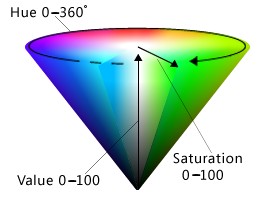

**HSV** est une autre manière de représenter les couleurs.
Au lieu de RGB,  HSV représente la couleur avec:
```
H = Hue / Teinte
S = Saturation
V = Value / Luminosité
```

### Pourquoi HSV est souvent mieux que RGB ?

Parce que HSV sépare mieux la couleur de la luminosité.
En RGB, si la lumière change, les valeurs R, G et B changent toutes en même temps. Donc une même eau peut paraître très différente selon l’éclairage.
En HSV, on peut dire par exemple :
```
Je cherche les pixels dont la teinte est proche du bleu,
avec une saturation suffisante,
et une luminosité acceptable.
```

### Comment ça marche la méthode HSV :
-  convertir l’image de RGB vers HSV ;
- définir une plage de valeurs acceptables pour l’eau ;
- créer un masque avec les pixels qui rentrent dans cette plage ;
- nettoyer le masque avec des opérations morphologiques ;
- afficher le résultat.

### Pourquoi ce n’est pas la meilleure méthode ?
Parce qu’elle repose sur des règles fixes.
Elle peut marcher dans une image simple, avec une eau bien visible et une lumière stable. Mais dans un vrai contexte industriel, elle devient vite limitée.

Les gros problèmes sont :

- l’eau ne garde pas toujours la même couleur ;
- les reflets peuvent être détectés comme de l’eau ;
- le sol mouillé peut ressembler à de l’eau ;
- la boue ou la mousse peuvent cacher l’eau ;
- la lumière change selon l’heure ou la caméra ;
- chaque caméra peut avoir un angle différent ;
- une règle qui marche sur une image peut échouer sur une autre.

Donc le seuillage couleur est utile comme **baseline**, c’est-à-dire comme première méthode simple pour comparer. Mais cette methode n'est pas assez suffisante pour être la solution finale.

Objectif : construire une premiere methode simple, sans apprentissage, pour comparer ensuite avec le Machine Learning et le Deep Learning.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from water_detection_methods.baselines import blue_dominance_threshold
from water_detection_methods.data import find_water_v2_pairs, load_pair
from water_detection_methods.metrics import dice_coefficient, intersection_over_union
from water_detection_methods.visualization import show_image_mask_overlay

In [ ]:
pairs = find_water_v2_pairs(ROOT / "water_v2")
image, true_mask = load_pair(*pairs[0], size=(384, 256))
pred_mask = blue_dominance_threshold(image)

print("IoU:", intersection_over_union(true_mask, pred_mask))
print("Dice:", dice_coefficient(true_mask, pred_mask))
show_image_mask_overlay(image, pred_mask, title="Prediction baseline")